In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [21]:
# AND gate

X_AND = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

Y_AND = np.array([
    0,
    0,
    0,
    1
], dtype=float)


# XOR gate

X_XOR = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

Y_XOR = np.array([
    0,
    1,
    1,
    0
], dtype=float)


print("AND Dataset")
print("X =")
print(X_AND)
print("Y =", Y_AND)

print("\nXOR Dataset")
print("X =")
print(X_XOR)
print("Y =", Y_XOR)

AND Dataset
X =
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Y = [0. 0. 0. 1.]

XOR Dataset
X =
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Y = [0. 1. 1. 0.]


In [22]:
# ============================================================
# A1 - BASIC PERCEPTRON FUNCTIONS
# ============================================================

def summation_unit(inputs, weights, bias):
    """
    Calculates:
        net = bias + sum(inputs * weights)
    """
    inputs = np.asarray(inputs, dtype=float)
    weights = np.asarray(weights, dtype=float)

    return bias + np.dot(inputs, weights)


def step_activation(x):
    if x >= 0:
        return 1
    return 0


def bipolar_step_activation(x):
    if x >= 0:
        return 1
    return -1


def sigmoid_activation(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))


def tanh_activation(x):
    return np.tanh(x)


def relu_activation(x):
    return max(0, x)


def leaky_relu_activation(x):
    if x >= 0:
        return x
    return 0.01 * x


def comparator(target, prediction):
    """
    Calculates error.
    """
    return target - prediction


def calculate_sse(targets, predictions):
    """
    Sum Squared Error.
    """
    targets = np.asarray(targets, dtype=float)
    predictions = np.asarray(predictions, dtype=float)

    return np.sum((targets - predictions) ** 2)

In [23]:
inputs = np.array([1, 2])
weights = np.array([0.5, 0.25])
bias = 0.1

net = summation_unit(
    inputs,
    weights,
    bias
)

print("Summation:", net)
print("Step:", step_activation(net))
print("Bipolar Step:", bipolar_step_activation(net))
print("Sigmoid:", sigmoid_activation(net))
print("TanH:", tanh_activation(net))
print("ReLU:", relu_activation(net))
print("Leaky ReLU:", leaky_relu_activation(net))

Summation: 1.1
Step: 1
Bipolar Step: 1
Sigmoid: 0.7502601055951177
TanH: 0.8004990217606297
ReLU: 1.1
Leaky ReLU: 1.1


In [24]:
# ============================================================
# A2 - CUSTOM PERCEPTRON
# ============================================================

def train_perceptron(
    X,
    y,
    learning_rate,
    activation,
    initial_bias,
    initial_weights,
    max_iterations=1000,
    convergence_error=0.002
):
    """
    Train a single-layer perceptron.
    """

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    weights = np.array(
        initial_weights,
        dtype=float
    )

    bias = float(initial_bias)

    error_history = []

    for epoch in range(1, max_iterations + 1):

        # ----------------------------------------------------
        # Training
        # ----------------------------------------------------

        for i in range(len(X)):

            net = summation_unit(
                X[i],
                weights,
                bias
            )

            prediction = activation(net)

            error = comparator(
                y[i],
                prediction
            )

            # Perceptron learning rule
            weights = (
                weights
                + learning_rate * error * X[i]
            )

            bias = (
                bias
                + learning_rate * error
            )

        # ----------------------------------------------------
        # Calculate SSE after epoch
        # ----------------------------------------------------

        predictions = []

        for sample in X:

            net = summation_unit(
                sample,
                weights,
                bias
            )

            prediction = activation(net)

            predictions.append(prediction)

        sse = calculate_sse(
            y,
            predictions
        )

        error_history.append(sse)

        if sse <= convergence_error:

            return {
                "weights": weights,
                "bias": bias,
                "iterations": epoch,
                "errors": error_history,
                "converged": True
            }

    return {
        "weights": weights,
        "bias": bias,
        "iterations": max_iterations,
        "errors": error_history,
        "converged": False
    }

In [25]:
# ============================================================
# A2 - AND GATE
# ============================================================

and_result = train_perceptron(
    X=X_AND,
    y=Y_AND,
    learning_rate=0.05,
    activation=step_activation,
    initial_bias=10,
    initial_weights=[0.2, -0.75],
    max_iterations=1000,
    convergence_error=0.002
)

print("Final Weights:", and_result["weights"])
print("Final Bias:", and_result["bias"])
print("Iterations:", and_result["iterations"])
print("Converged:", and_result["converged"])
print("Final SSE:", and_result["errors"][-1])

Final Weights: [0.1  0.05]
Final Bias: -0.10000000000000765
Iterations: 129
Converged: True
Final SSE: 0.0


In [26]:
def perceptron_predict(
    X,
    weights,
    bias,
    activation
):
    predictions = []

    for sample in X:

        net = summation_unit(
            sample,
            weights,
            bias
        )

        predictions.append(
            activation(net)
        )

    return np.array(predictions)


and_predictions = perceptron_predict(
    X_AND,
    and_result["weights"],
    and_result["bias"],
    step_activation
)

print("Actual:")
print(Y_AND.astype(int))

print("\nPredicted:")
print(and_predictions.astype(int))

Actual:
[0 0 0 1]

Predicted:
[0 0 0 1]


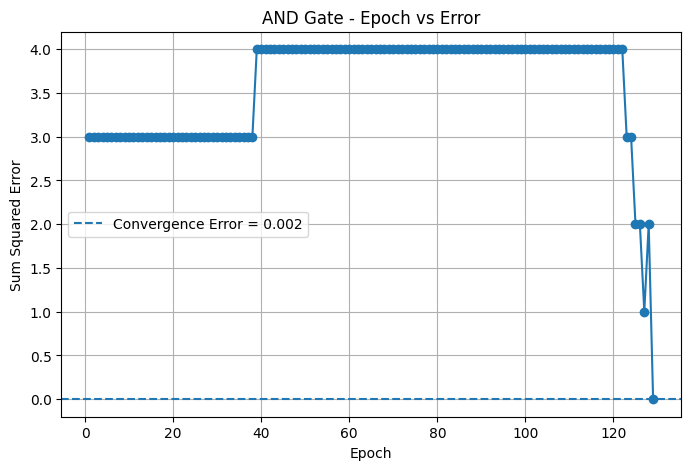

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(and_result["errors"]) + 1
    ),
    and_result["errors"],
    marker="o"
)

plt.axhline(
    y=0.002,
    linestyle="--",
    label="Convergence Error = 0.002"
)

plt.xlabel("Epoch")
plt.ylabel("Sum Squared Error")
plt.title("AND Gate - Epoch vs Error")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
# ============================================================
# A3 - GENERAL ACTIVATION PERCEPTRON
# ============================================================

def activation_derivative(
    net,
    activation_name
):

    if activation_name == "sigmoid":

        output = sigmoid_activation(net)

        return output * (1 - output)

    elif activation_name == "relu":

        if net > 0:
            return 1
        return 0

    elif activation_name == "tanh":

        output = tanh_activation(net)

        return 1 - output ** 2

    elif activation_name == "leaky_relu":

        if net > 0:
            return 1
        return 0.01

    return 1


def train_with_activation(
    X,
    y,
    learning_rate,
    activation_name,
    initial_bias=10,
    initial_weights=None,
    max_iterations=1000,
    convergence_error=0.002
):

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    if initial_weights is None:
        weights = np.zeros(X.shape[1])
    else:
        weights = np.array(
            initial_weights,
            dtype=float
        )

    bias = initial_bias

    errors = []

    for epoch in range(
        1,
        max_iterations + 1
    ):

        for i in range(len(X)):

            net = summation_unit(
                X[i],
                weights,
                bias
            )

            if activation_name == "bipolar":

                prediction = bipolar_step_activation(net)

                target = 1 if y[i] == 1 else -1

                error = target - prediction

                weights += (
                    learning_rate
                    * error
                    * X[i]
                )

                bias += learning_rate * error

            else:

                if activation_name == "sigmoid":

                    prediction = sigmoid_activation(net)

                elif activation_name == "relu":

                    prediction = relu_activation(net)

                elif activation_name == "tanh":

                    prediction = tanh_activation(net)

                elif activation_name == "leaky_relu":

                    prediction = leaky_relu_activation(net)

                error = y[i] - prediction

                derivative = activation_derivative(
                    net,
                    activation_name
                )

                delta = error * derivative

                weights += (
                    learning_rate
                    * delta
                    * X[i]
                )

                bias += (
                    learning_rate
                    * delta
                )

        # ----------------------------------------------------
        # Calculate error after epoch
        # ----------------------------------------------------

        predictions = []

        for sample in X:

            net = summation_unit(
                sample,
                weights,
                bias
            )

            if activation_name == "bipolar":
                output = bipolar_step_activation(net)

            elif activation_name == "sigmoid":
                output = sigmoid_activation(net)

            elif activation_name == "relu":
                output = relu_activation(net)

            elif activation_name == "tanh":
                output = tanh_activation(net)

            elif activation_name == "leaky_relu":
                output = leaky_relu_activation(net)

            predictions.append(output)

        if activation_name == "bipolar":

            comparison_targets = np.where(
                y == 1,
                1,
                -1
            )

        else:

            comparison_targets = y

        sse = calculate_sse(
            comparison_targets,
            predictions
        )

        errors.append(sse)

        if sse <= convergence_error:

            break

    return {
        "weights": weights,
        "bias": bias,
        "iterations": epoch,
        "errors": errors,
        "converged": sse <= convergence_error
    }

In [29]:
# ============================================================
# A3 - ACTIVATION COMPARISON
# ============================================================

activation_names = [
    "bipolar",
    "sigmoid",
    "relu"
]

activation_results = {}

for name in activation_names:

    result = train_with_activation(
        X_AND,
        Y_AND,
        learning_rate=0.05,
        activation_name=name,
        initial_bias=10,
        initial_weights=[0.2, -0.75],
        max_iterations=1000,
        convergence_error=0.002
    )

    activation_results[name] = result


activation_table = pd.DataFrame({

    "Activation": activation_names,

    "Iterations": [
        activation_results[name]["iterations"]
        for name in activation_names
    ],

    "Converged": [
        activation_results[name]["converged"]
        for name in activation_names
    ],

    "Final SSE": [
        activation_results[name]["errors"][-1]
        for name in activation_names
    ]

})

display(activation_table)

,Activation,Iterations,Converged,Final SSE
0,bipolar,67,True,0.000000
1,sigmoid,1000,False,2.999638
2,relu,1000,False,1.000000


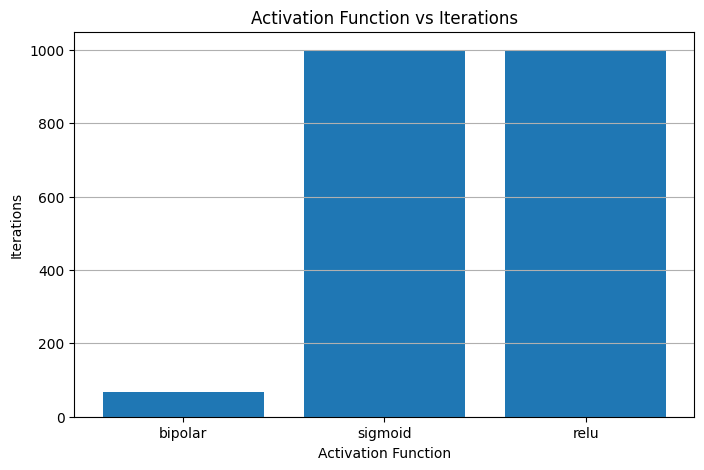

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    activation_table["Activation"],
    activation_table["Iterations"]
)

plt.xlabel("Activation Function")
plt.ylabel("Iterations")
plt.title("Activation Function vs Iterations")
plt.grid(axis="y")

plt.show()

In [31]:
# ============================================================
# A4 - LEARNING RATE EXPERIMENT
# ============================================================

learning_rates = np.arange(
    0.1,
    1.1,
    0.1
)

learning_rate_results = []

for learning_rate in learning_rates:

    result = train_perceptron(
        X_AND,
        Y_AND,
        learning_rate=learning_rate,
        activation=step_activation,
        initial_bias=10,
        initial_weights=[0.2, -0.75],
        max_iterations=1000,
        convergence_error=0.002
    )

    learning_rate_results.append({

        "Learning Rate":
            round(learning_rate, 1),

        "Iterations":
            result["iterations"],

        "Converged":
            result["converged"],

        "Final SSE":
            result["errors"][-1]
    })


learning_rate_table = pd.DataFrame(
    learning_rate_results
)

display(learning_rate_table)

,Learning Rate,Iterations,Converged,Final SSE
0,0.1,67,True,0.0
1,0.2,36,True,0.0
2,0.3,22,True,0.0
3,0.4,22,True,0.0
4,0.5,18,True,0.0
5,0.6,18,True,0.0
6,0.7,14,True,0.0
7,0.8,13,True,0.0
8,0.9,12,True,0.0
9,1.0,11,True,0.0


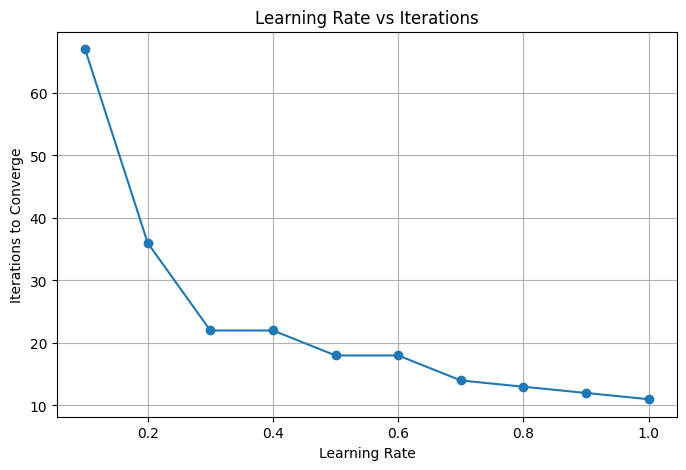

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    learning_rate_table["Learning Rate"],
    learning_rate_table["Iterations"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Iterations to Converge")
plt.title("Learning Rate vs Iterations")
plt.grid(True)

plt.show()

In [33]:
# ============================================================
# A5 - XOR WITH SINGLE-LAYER PERCEPTRON
# ============================================================

xor_result = train_perceptron(
    X_XOR,
    Y_XOR,
    learning_rate=0.05,
    activation=step_activation,
    initial_bias=10,
    initial_weights=[0.2, -0.75],
    max_iterations=1000,
    convergence_error=0.002
)

print("Iterations:", xor_result["iterations"])
print("Converged:", xor_result["converged"])
print("Final SSE:", xor_result["errors"][-1])

Iterations: 1000
Converged: False
Final SSE: 3.0


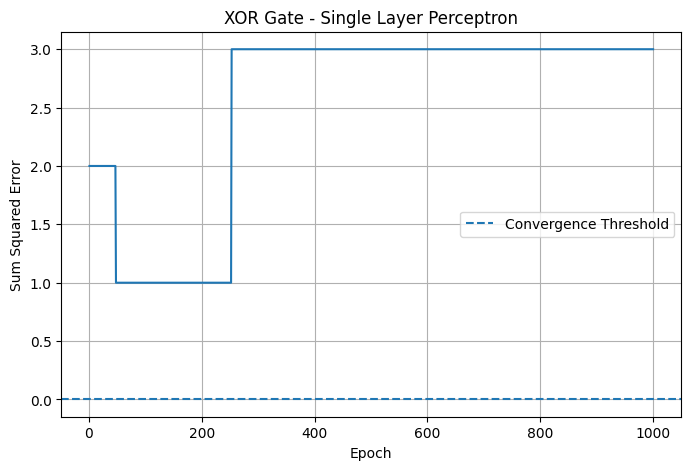

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(
        1,
        len(xor_result["errors"]) + 1
    ),
    xor_result["errors"]
)

plt.axhline(
    y=0.002,
    linestyle="--",
    label="Convergence Threshold"
)

plt.xlabel("Epoch")
plt.ylabel("Sum Squared Error")
plt.title("XOR Gate - Single Layer Perceptron")
plt.legend()
plt.grid(True)

plt.show()

In [35]:
# ============================================================
# A6 - CUSTOMER DATA
# ============================================================

customer_data = pd.DataFrame({

    "Customer": [
        "C_1",
        "C_2",
        "C_3",
        "C_4",
        "C_5",
        "C_6",
        "C_7",
        "C_8",
        "C_9",
        "C_10"
    ],

    "Candies": [
        20, 16, 27, 19, 24,
        22, 15, 18, 21, 16
    ],

    "Mangoes": [
        6, 3, 6, 1, 4,
        1, 4, 4, 1, 2
    ],

    "Milk_Packets": [
        2, 6, 2, 2, 2,
        5, 2, 2, 4, 4
    ],

    "Payment": [
        386, 289, 393, 110, 280,
        167, 271, 274, 148, 198
    ],

    "High_Value": [
        1, 1, 1, 0, 1,
        0, 1, 1, 0, 0
    ]
})

display(customer_data)

,Customer,Candies,Mangoes,Milk_Packets,Payment,High_Value
0,C_1,20,6,2,386,1
1,C_2,16,3,6,289,1
2,C_3,27,6,2,393,1
3,C_4,19,1,2,110,0
4,C_5,24,4,2,280,1
5,C_6,22,1,5,167,0
6,C_7,15,4,2,271,1
7,C_8,18,4,2,274,1
8,C_9,21,1,4,148,0
9,C_10,16,2,4,198,0


In [36]:
# ============================================================
# A6 - CUSTOMER PREPROCESSING
# ============================================================

customer_features = customer_data[
    [
        "Candies",
        "Mangoes",
        "Milk_Packets",
        "Payment"
    ]
].values

customer_target = customer_data[
    "High_Value"
].values


scaler = StandardScaler()

customer_features_scaled = scaler.fit_transform(
    customer_features
)

print(
    "Feature Matrix Shape:",
    customer_features_scaled.shape
)

print(
    "Target Shape:",
    customer_target.shape
)

Feature Matrix Shape: (10, 4)
Target Shape: (10,)


In [37]:
# ============================================================
# A6 - CUSTOMER SIGMOID PERCEPTRON
# ============================================================

customer_result = train_with_activation(
    customer_features_scaled,
    customer_target,
    learning_rate=0.05,
    activation_name="sigmoid",
    initial_bias=0,
    initial_weights=[
        0.0,
        0.0,
        0.0,
        0.0
    ],
    max_iterations=1000,
    convergence_error=0.002
)

print("Weights:")
print(customer_result["weights"])

print("\nBias:")
print(customer_result["bias"])

print("\nIterations:")
print(customer_result["iterations"])

print("\nConverged:")
print(customer_result["converged"])

print("\nFinal SSE:")
print(customer_result["errors"][-1])

Weights:
[-0.03430291  2.42479747  0.09456067  2.72616667]

Bias:
1.1311889023033959

Iterations:
1000

Converged:
False

Final SSE:
0.034147447870484744


In [38]:
# ============================================================
# A6 - CUSTOMER PREDICTIONS
# ============================================================

customer_probabilities = []

for sample in customer_features_scaled:

    net = summation_unit(
        sample,
        customer_result["weights"],
        customer_result["bias"]
    )

    probability = sigmoid_activation(net)

    customer_probabilities.append(
        probability
    )


customer_probabilities = np.array(
    customer_probabilities
)

customer_predictions = (
    customer_probabilities >= 0.5
).astype(int)


customer_output = customer_data[
    ["Customer", "High_Value"]
].copy()

customer_output[
    "Predicted_Probability"
] = np.round(
    customer_probabilities,
    3
)

customer_output[
    "Predicted_Class"
] = customer_predictions


display(customer_output)

,Customer,High_Value,Predicted_Probability,Predicted_Class
0,C_1,1,1.000,1
1,C_2,1,0.902,1
2,C_3,1,1.000,1
3,C_4,0,0.002,0
4,C_5,1,0.949,1
5,C_6,0,0.014,0
6,C_7,1,0.940,1
7,C_8,1,0.943,1
8,C_9,0,0.008,0
9,C_10,0,0.122,0


In [39]:
customer_accuracy = accuracy_score(
    customer_target,
    customer_predictions
)

print(
    "Customer Accuracy:",
    round(customer_accuracy * 100, 2),
    "%"
)

Customer Accuracy: 100.0 %


In [40]:
# ============================================================
# A7 - PSEUDO INVERSE
# ============================================================

def pseudo_inverse_weights(X, y):

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    # Add bias column
    X_bias = np.column_stack([
        np.ones(X.shape[0]),
        X
    ])

    weights = np.linalg.pinv(
        X_bias
    ) @ y

    return weights


pseudo_weights = pseudo_inverse_weights(
    customer_features_scaled,
    customer_target
)

print("Pseudo-Inverse Weights:")
print(np.round(pseudo_weights, 4))

Pseudo-Inverse Weights:
[ 0.6    -0.0944  0.2171 -0.0134  0.2342]


In [41]:
X_customer_bias = np.column_stack([
    np.ones(
        customer_features_scaled.shape[0]
    ),
    customer_features_scaled
])

pseudo_output = (
    X_customer_bias @ pseudo_weights
)

pseudo_predictions = (
    pseudo_output >= 0.5
).astype(int)


pseudo_accuracy = accuracy_score(
    customer_target,
    pseudo_predictions
)


print(
    "Perceptron Accuracy:",
    round(customer_accuracy * 100, 2),
    "%"
)

print(
    "Pseudo-Inverse Accuracy:",
    round(pseudo_accuracy * 100, 2),
    "%"
)

Perceptron Accuracy: 100.0 %
Pseudo-Inverse Accuracy: 100.0 %


In [42]:
comparison_table = pd.DataFrame({

    "Method": [
        "Sigmoid Perceptron",
        "Matrix Pseudo-Inverse"
    ],

    "Accuracy (%)": [
        round(customer_accuracy * 100, 2),
        round(pseudo_accuracy * 100, 2)
    ]
})

display(comparison_table)

,Method,Accuracy (%)
0,Sigmoid Perceptron,100.0
1,Matrix Pseudo-Inverse,100.0


In [43]:
# ============================================================
# A8 - BACKPROPAGATION FUNCTIONS
# ============================================================

def initialize_network(
    input_nodes,
    hidden_nodes,
    output_nodes,
    seed=42
):

    rng = np.random.default_rng(seed)

    weights_input_hidden = rng.uniform(
        -0.5,
        0.5,
        size=(input_nodes, hidden_nodes)
    )

    weights_hidden_output = rng.uniform(
        -0.5,
        0.5,
        size=(hidden_nodes, output_nodes)
    )

    bias_hidden = np.zeros(
        hidden_nodes
    )

    bias_output = np.zeros(
        output_nodes
    )

    return (
        weights_input_hidden,
        weights_hidden_output,
        bias_hidden,
        bias_output
    )


def forward_pass(
    x,
    weights_input_hidden,
    weights_hidden_output,
    bias_hidden,
    bias_output
):

    hidden_net = (
        np.dot(
            x,
            weights_input_hidden
        )
        + bias_hidden
    )

    hidden_output = sigmoid_activation(
        hidden_net
    )

    output_net = (
        np.dot(
            hidden_output,
            weights_hidden_output
        )
        + bias_output
    )

    output = sigmoid_activation(
        output_net
    )

    return (
        hidden_output,
        output
    )


def train_backpropagation(
    X,
    y,
    learning_rate=0.05,
    hidden_nodes=2,
    max_iterations=1000,
    convergence_error=0.002,
    seed=42
):

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    if y.ndim == 1:
        y = y.reshape(-1, 1)

    (
        weights_input_hidden,
        weights_hidden_output,
        bias_hidden,
        bias_output
    ) = initialize_network(
        X.shape[1],
        hidden_nodes,
        y.shape[1],
        seed
    )

    error_history = []

    for epoch in range(
        1,
        max_iterations + 1
    ):

        total_error = 0

        for x_sample, target in zip(
            X,
            y
        ):

            # ------------------------------
            # Forward propagation
            # ------------------------------

            hidden_output, output = forward_pass(
                x_sample,
                weights_input_hidden,
                weights_hidden_output,
                bias_hidden,
                bias_output
            )

            error = target - output

            total_error += np.sum(
                error ** 2
            )

            # ------------------------------
            # Output delta
            # ------------------------------

            output_delta = (
                error
                * output
                * (1 - output)
            )

            # ------------------------------
            # Hidden delta
            # ------------------------------

            hidden_delta = (
                hidden_output
                * (1 - hidden_output)
                * np.dot(
                    weights_hidden_output,
                    output_delta
                )
            )

            # ------------------------------
            # Update hidden-output weights
            # ------------------------------

            weights_hidden_output += (
                learning_rate
                * np.outer(
                    hidden_output,
                    output_delta
                )
            )

            bias_output += (
                learning_rate
                * output_delta
            )

            # ------------------------------
            # Update input-hidden weights
            # ------------------------------

            weights_input_hidden += (
                learning_rate
                * np.outer(
                    x_sample,
                    hidden_delta
                )
            )

            bias_hidden += (
                learning_rate
                * hidden_delta
            )

        error_history.append(
            total_error
        )

        if total_error <= convergence_error:
            break

    return {
        "input_hidden": weights_input_hidden,
        "hidden_output": weights_hidden_output,
        "hidden_bias": bias_hidden,
        "output_bias": bias_output,
        "iterations": epoch,
        "errors": error_history,
        "converged": total_error <= convergence_error
    }

In [44]:
# ============================================================
# A8 - AND BACKPROPAGATION
# ============================================================

and_network = train_backpropagation(
    X_AND,
    Y_AND,
    learning_rate=0.05,
    hidden_nodes=2,
    max_iterations=1000,
    convergence_error=0.002,
    seed=42
)

print(
    "Iterations:",
    and_network["iterations"]
)

print(
    "Converged:",
    and_network["converged"]
)

print(
    "Final SSE:",
    and_network["errors"][-1]
)

Iterations: 1000
Converged: False
Final SSE: 0.7028757930816929


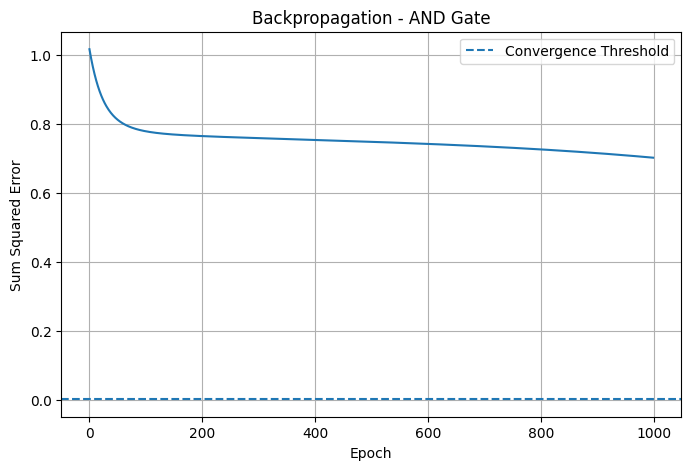

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    and_network["errors"]
)

plt.axhline(
    y=0.002,
    linestyle="--",
    label="Convergence Threshold"
)

plt.xlabel("Epoch")
plt.ylabel("Sum Squared Error")
plt.title("Backpropagation - AND Gate")
plt.legend()
plt.grid(True)

plt.show()

In [46]:
def network_predict(
    X,
    network
):

    predictions = []

    for sample in X:

        hidden_output, output = forward_pass(
            sample,
            network["input_hidden"],
            network["hidden_output"],
            network["hidden_bias"],
            network["output_bias"]
        )

        predictions.append(
            output
        )

    return np.array(
        predictions
    )


and_probabilities = network_predict(
    X_AND,
    and_network
).flatten()

and_predictions = (
    and_probabilities >= 0.5
).astype(int)


print("Actual:")
print(Y_AND.astype(int))

print("\nPredicted:")
print(and_predictions)

print(
    "\nAccuracy:",
    round(
        accuracy_score(
            Y_AND,
            and_predictions
        ) * 100,
        2
    ),
    "%"
)

Actual:
[0 0 0 1]

Predicted:
[0 0 0 0]

Accuracy: 75.0 %


In [47]:
# ============================================================
# A9 - XOR BACKPROPAGATION
# ============================================================

xor_network = train_backpropagation(
    X_XOR,
    Y_XOR,
    learning_rate=0.05,
    hidden_nodes=2,
    max_iterations=1000,
    convergence_error=0.002,
    seed=42
)

print(
    "Iterations:",
    xor_network["iterations"]
)

print(
    "Converged:",
    xor_network["converged"]
)

print(
    "Final SSE:",
    xor_network["errors"][-1]
)

Iterations: 1000
Converged: False
Final SSE: 1.0053384745912466


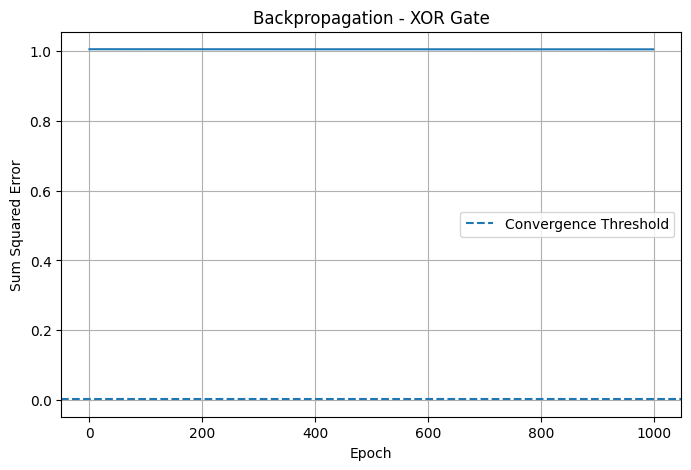

In [48]:
plt.figure(figsize=(8, 5))

plt.plot(
    xor_network["errors"]
)

plt.axhline(
    y=0.002,
    linestyle="--",
    label="Convergence Threshold"
)

plt.xlabel("Epoch")
plt.ylabel("Sum Squared Error")
plt.title("Backpropagation - XOR Gate")
plt.legend()
plt.grid(True)

plt.show()

In [49]:
xor_probabilities = network_predict(
    X_XOR,
    xor_network
).flatten()

xor_predictions = (
    xor_probabilities >= 0.5
).astype(int)


print("Actual:")
print(Y_XOR.astype(int))

print("\nPredicted:")
print(xor_predictions)

print(
    "\nAccuracy:",
    round(
        accuracy_score(
            Y_XOR,
            xor_predictions
        ) * 100,
        2
    ),
    "%"
)

Actual:
[0 1 1 0]

Predicted:
[1 1 0 0]

Accuracy: 50.0 %


In [50]:
# ============================================================
# A10 - TWO OUTPUT NODES
# ============================================================

Y_AND_2_OUTPUT = np.array([
    [1, 0],
    [1, 0],
    [1, 0],
    [0, 1]
], dtype=float)


two_output_network = train_backpropagation(
    X_AND,
    Y_AND_2_OUTPUT,
    learning_rate=0.05,
    hidden_nodes=2,
    max_iterations=1000,
    convergence_error=0.002,
    seed=42
)

print(
    "Iterations:",
    two_output_network["iterations"]
)

print(
    "Converged:",
    two_output_network["converged"]
)

print(
    "Final SSE:",
    two_output_network["errors"][-1]
)

Iterations: 1000
Converged: False
Final SSE: 1.1529157810933888


In [51]:
two_output_values = network_predict(
    X_AND,
    two_output_network
)

print("Raw Network Output:")
print(
    np.round(
        two_output_values,
        3
    )
)


decoded_output = np.argmax(
    two_output_values,
    axis=1
)

print("\nDecoded Output:")
print(decoded_output)

print("\nActual Output:")
print(Y_AND.astype(int))

Raw Network Output:
[[0.82  0.195]
 [0.717 0.282]
 [0.704 0.29 ]
 [0.598 0.377]]

Decoded Output:
[0 0 0 0]

Actual Output:
[0 0 0 1]


In [52]:
# ============================================================
# A11 - MLP CLASSIFIER AND
# ============================================================

mlp_and = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation="logistic",
    solver="lbfgs",
    learning_rate_init=0.05,
    max_iter=1000,
    random_state=42
)

mlp_and.fit(
    X_AND,
    Y_AND
)

mlp_and_predictions = mlp_and.predict(
    X_AND
)

print("Actual:")
print(Y_AND.astype(int))

print("\nPredicted:")
print(mlp_and_predictions)

print(
    "\nAccuracy:",
    round(
        accuracy_score(
            Y_AND,
            mlp_and_predictions
        ) * 100,
        2
    ),
    "%"
)

Actual:
[0 0 0 1]

Predicted:
[0. 0. 0. 1.]

Accuracy: 100.0 %


In [53]:
# ============================================================
# A11 - MLP CLASSIFIER XOR
# ============================================================

mlp_xor = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation="logistic",
    solver="lbfgs",
    learning_rate_init=0.05,
    max_iter=1000,
    random_state=42
)

mlp_xor.fit(
    X_XOR,
    Y_XOR
)

mlp_xor_predictions = mlp_xor.predict(
    X_XOR
)

print("Actual:")
print(Y_XOR.astype(int))

print("\nPredicted:")
print(mlp_xor_predictions)

print(
    "\nAccuracy:",
    round(
        accuracy_score(
            Y_XOR,
            mlp_xor_predictions
        ) * 100,
        2
    ),
    "%"
)

Actual:
[0 1 1 0]

Predicted:
[1. 1. 1. 0.]

Accuracy: 75.0 %


In [54]:
# ============================================================
# A12 - LOAD PROJECT DATASET
# ============================================================

from google.colab import drive

drive.mount(
    "/content/drive"
)

csv_path = (
    "/content/drive/MyDrive/"
    "glaucoma_handcrafted_features.csv"
)

glaucoma_df = pd.read_csv(
    csv_path
)

print(
    "Dataset Shape:",
    glaucoma_df.shape
)

display(
    glaucoma_df.head()
)

Mounted at /content/drive
Dataset Shape: (485, 13)


,disc_area,cup_area,cup_disc_area_ratio,disc_perimeter,cup_perimeter,disc_width,disc_height,cup_width,cup_height,cup_disc_width_ratio,cup_disc_height_ratio,image_id,class
0,179399,30100,0.167782,1583.959581,646.440686,465,492,198,194,0.425806,0.394309,r2_Im038,normal
1,139202,16487,0.118439,1401.994069,477.002089,375,467,146,144,0.389333,0.308351,r2_Im092,normal
2,146567,8882,0.060600,1430.420478,358.534052,421,445,91,126,0.216152,0.283146,r2_Im070,normal
3,53820,10800,0.200669,876.205185,389.889392,250,285,113,127,0.452000,0.445614,r1_Im143,normal
4,81804,20817,0.254474,1080.714852,555.327989,293,363,135,205,0.460751,0.564738,r1_Im054,normal


In [55]:
# ============================================================
# A12 - SELECT GLAUCOMA FEATURES
# ============================================================

feature_columns = [
    "disc_area",
    "cup_area",
    "cup_disc_area_ratio",
    "disc_perimeter",
    "cup_perimeter",
    "disc_width",
    "disc_height",
    "cup_width",
    "cup_height",
    "cup_disc_width_ratio",
    "cup_disc_height_ratio"
]

X_glaucoma = glaucoma_df[
    feature_columns
].values


# Change this only if your CSV uses another target-column name.

if "class" in glaucoma_df.columns:

    y_glaucoma = glaucoma_df[
        "class"
    ].values

elif "label" in glaucoma_df.columns:

    y_glaucoma = glaucoma_df[
        "label"
    ].values

else:

    raise ValueError(
        "Target column not found."
    )


print(
    "Feature Shape:",
    X_glaucoma.shape
)

print(
    "Target Shape:",
    y_glaucoma.shape
)

Feature Shape: (485, 11)
Target Shape: (485,)


In [56]:
# ============================================================
# A12 - TARGET ENCODING
# ============================================================

if y_glaucoma.dtype == object:

    y_glaucoma = np.array([

        1
        if str(label).lower() == "normal"
        else 0

        for label in y_glaucoma

    ])


print(
    "Classes:",
    np.unique(y_glaucoma)
)

Classes: [0 1]


In [57]:
# ============================================================
# A12 - TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X_glaucoma,
    y_glaucoma,

    test_size=0.30,

    random_state=42,

    stratify=y_glaucoma
)


scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)


print(
    "Training Shape:",
    X_train.shape
)

print(
    "Testing Shape:",
    X_test.shape
)

Training Shape: (339, 11)
Testing Shape: (146, 11)


In [58]:
# ============================================================
# A12 - MLP CLASSIFIER
# ============================================================

glaucoma_mlp = MLPClassifier(

    hidden_layer_sizes=(16, 8),

    activation="relu",

    solver="adam",

    learning_rate_init=0.001,

    max_iter=2000,

    random_state=42,

    early_stopping=True,

    validation_fraction=0.15,

    n_iter_no_change=30
)


glaucoma_mlp.fit(
    X_train,
    y_train
)


glaucoma_predictions = glaucoma_mlp.predict(
    X_test
)


glaucoma_accuracy = accuracy_score(
    y_test,
    glaucoma_predictions
)


print(
    "Accuracy:",
    round(
        glaucoma_accuracy * 100,
        2
    ),
    "%"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        glaucoma_predictions
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        glaucoma_predictions
    )
)

print(
    "\nIterations:",
    glaucoma_mlp.n_iter_
)

Accuracy: 86.99 %

Confusion Matrix:
[[48  4]
 [15 79]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83        52
           1       0.95      0.84      0.89        94

    accuracy                           0.87       146
   macro avg       0.86      0.88      0.86       146
weighted avg       0.88      0.87      0.87       146


Iterations: 101
